In [8]:
import os
import pandas as pd

# 1. This loop searches the folders to find exactly where styles.csv is hiding
base_path = '/kaggle/input/datasets/'
csv_path = None

for root, dirs, files in os.walk(base_path):
    if 'styles.csv' in files:
        csv_path = os.path.join(root, 'styles.csv')
        image_path = os.path.join(root, 'images')
        break

# 2. Load the data using the dynamically found path
if csv_path:
    print(f"🎉 Found the data path! Loading from: {csv_path}")
    data = pd.read_csv(csv_path, on_bad_lines='skip')
    data = data.dropna()
    data = pd.DataFrame(data)
    print("🚀 Success! Total rows loaded:", len(data))
    print("🖼️ Image folder path is set to:", image_path)
else:
    print("❌ Could not find styles.csv. Let's list everything below to see where it went:")
    for root, dirs, files in os.walk(base_path):
        print(f"Folder: {root} contains files: {files[:5]}")


🎉 Found the data path! Loading from: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv
🚀 Success! Total rows loaded: 44077
🖼️ Image folder path is set to: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images


In [13]:
!pip install faiss-cpu transformers accelerate sentencepiece Pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 82.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.8 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cud

In [9]:
import pandas as pd

# The exact path Kaggle built for your CSV file
data = pd.read_csv(
    '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv',
    on_bad_lines = 'skip'
)

data = data.dropna()
data = pd.DataFrame(data)

# The exact path Kaggle built for your images folder
image_path = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images'

print("Data is locked and loaded! Total items:", len(data))


Data is locked and loaded! Total items: 44077


In [11]:
data

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume


[Setup] Using device: cuda

█████████████████████████████████████████████████████████████████
  AI PRODUCT INTELLIGENCE SYSTEM  –  Day 2 Homework
  CLIP + BLIP-2 + FAISS
█████████████████████████████████████████████████████████████████

[Dataset] Reading /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv …
[Dataset] CSV rows after dropna: 44077
[Dataset] Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']
[Dataset] Products with valid images: 200

[Embed] Generating CLIP embeddings for 200 products …
[Model] Loading CLIP ViT-B/32 …


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Model] CLIP ready ✓
[Embed] Done. Embedding matrix shape: (200, 512)

  TASK 1 – SMART PRODUCT RECOMMENDATION ENGINE
[Task1] Query category : Apparel  (confidence=0.254)
[Task1] Complement cats: ['Accessories', 'Footwear']
  [1] Image Men Sunglasses  (cat=Accessories, sim=0.735)
  [2] Louis Philippe Men Grey Sunglasses  (cat=Accessories, sim=0.734)
  [3] Ray-Ban Men Active Lifestyle Copper Sunglasses  (cat=Accessories, sim=0.717)
[Model] Loading BLIP-2 (Salesforce/blip2-opt-2.7b) …


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

[Model] BLIP-2 ready ✓
[Task1] BLIP-2 caption : "a man in a blue and white checkered shirt"


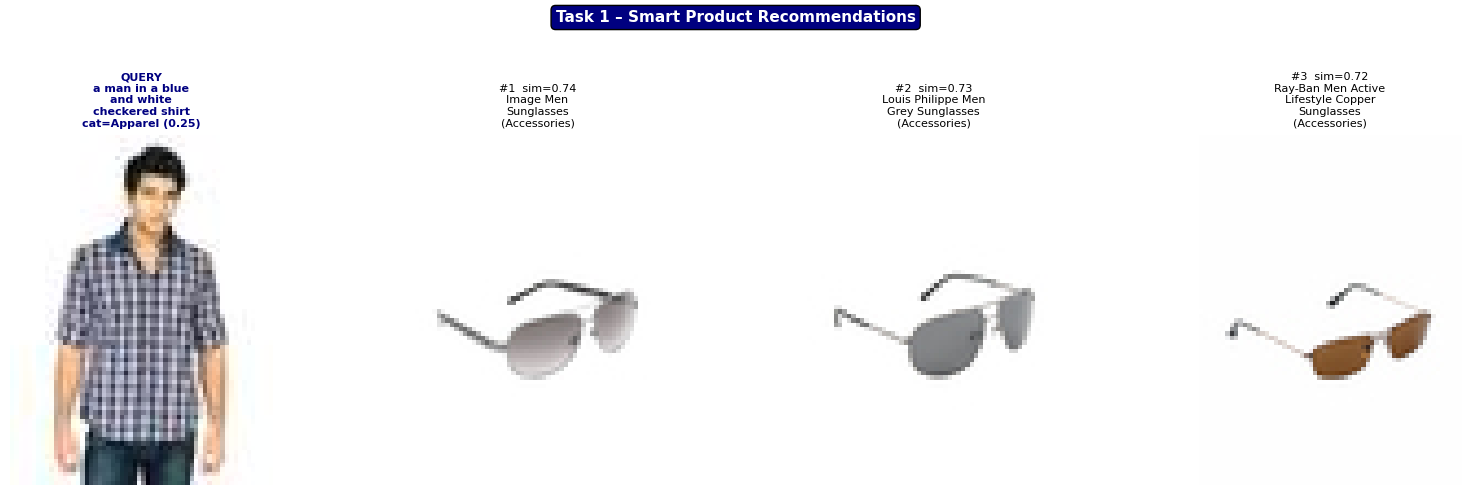

[Task1] Visualisation saved → task1_recommendations.png

  TASK 2 – UNIQUE PRODUCT CATALOG CREATION
[Task2] Original count : 200
[Task2] Catalog count  : 154
[Task2] Duplicates removed: 46

─────────────────────────────────────────────
  Cluster  1 │ rep='Turtle Check Men Navy Blue Shirt'
            │  dup='Fabindia Men Striped Green Shirt'  sim=0.924
            │  dup='Scullers Men  Green Check Shirt'  sim=0.937
            │  dup='Levis Men Check Red Shirts'  sim=0.933
  Cluster  2 │ rep='Peter England Men Party Blue Jeans'
  Cluster  3 │ rep='Titan Women Silver Watch'
  Cluster  4 │ rep='Manchester United Men Solid Black Track Pants'
  Cluster  5 │ rep='Puma Men Grey T-shirt'
  Cluster  6 │ rep='Inkfruit Mens Chain Reaction T-shirt'
  Cluster  7 │ rep='Jealous 21 Women Purple Shirt'
            │  dup='Lee Women Paula Blue Top'  sim=0.926
  Cluster  8 │ rep='Puma Men Pack of 3 Socks'
  Cluster  9 │ rep='Skagen Men Black Watch'
            │  dup='CASIO EDIFICE Men Black Dial Chron

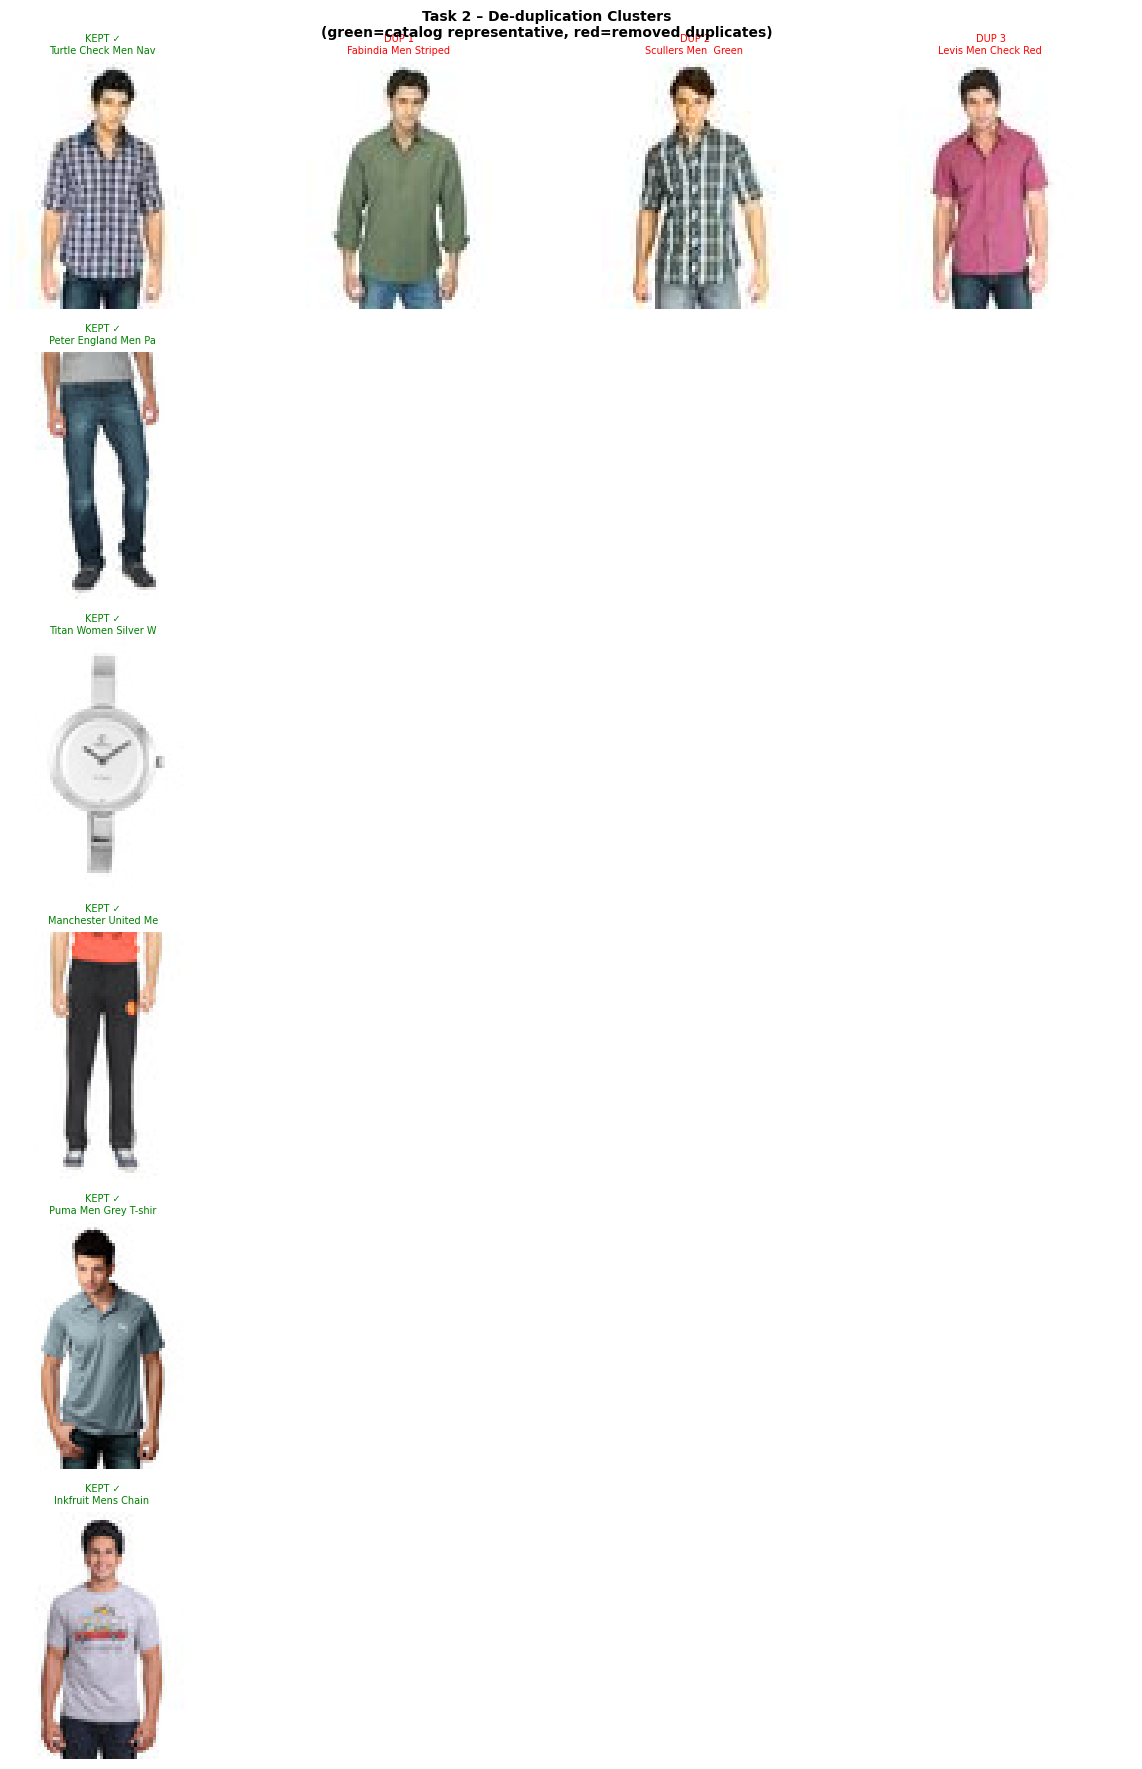

[Task2] Visualisation saved → task2_dedup_catalog.png

[Task2] Final catalog has 154 unique products.

  TASK 3 – REVERSE PRODUCT SEARCH  (Text → Image)
[Task3] Query: "blue casual shirt"

─────────────────────────────────────────────
  [1] Turtle Check Men Navy Blue Shirt  (cat=Apparel, score=0.266)
  [2] John Players Men Navy Blue Shirt  (cat=Apparel, score=0.266)
  [3] U.S. Polo Assn. Men White & Navy Blue Shirt  (cat=Apparel, score=0.261)
  [4] United Colors of Benetton Men Solid Blue Sweatshirt  (cat=Apparel, score=0.258)
  [5] John Players Men Brown Shirt  (cat=Apparel, score=0.256)


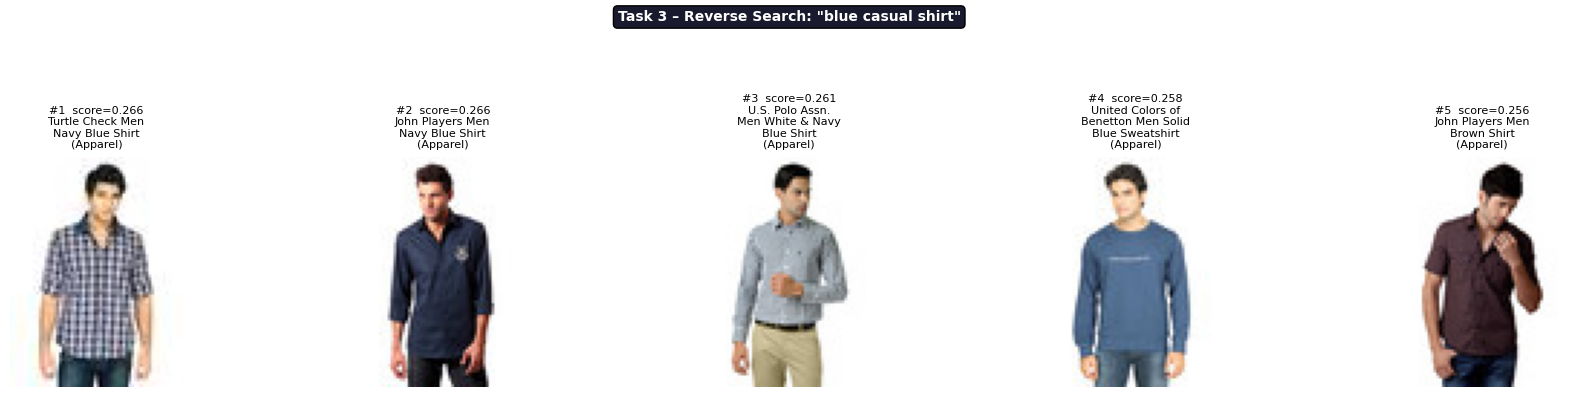

[Task3] Visualisation saved → task3_search_blue_casual_shirt.png

  TASK 3 – REVERSE PRODUCT SEARCH  (Text → Image)
[Task3] Query: "running sports shoe"

─────────────────────────────────────────────
  [1] Nike Men's Incinerate MSL White Blue Shoe  (cat=Footwear, score=0.318)
  [2] Nike Men Air Relentless 2 MSL White Sports Shoes  (cat=Footwear, score=0.311)
  [3] Puma Men Axis White & Grey Sports Shoes  (cat=Footwear, score=0.305)
  [4] Lotto Men Atlantica Black Sports Shoe  (cat=Footwear, score=0.298)
  [5] ADIDAS Men Blue Chill Sports Shoes  (cat=Footwear, score=0.296)


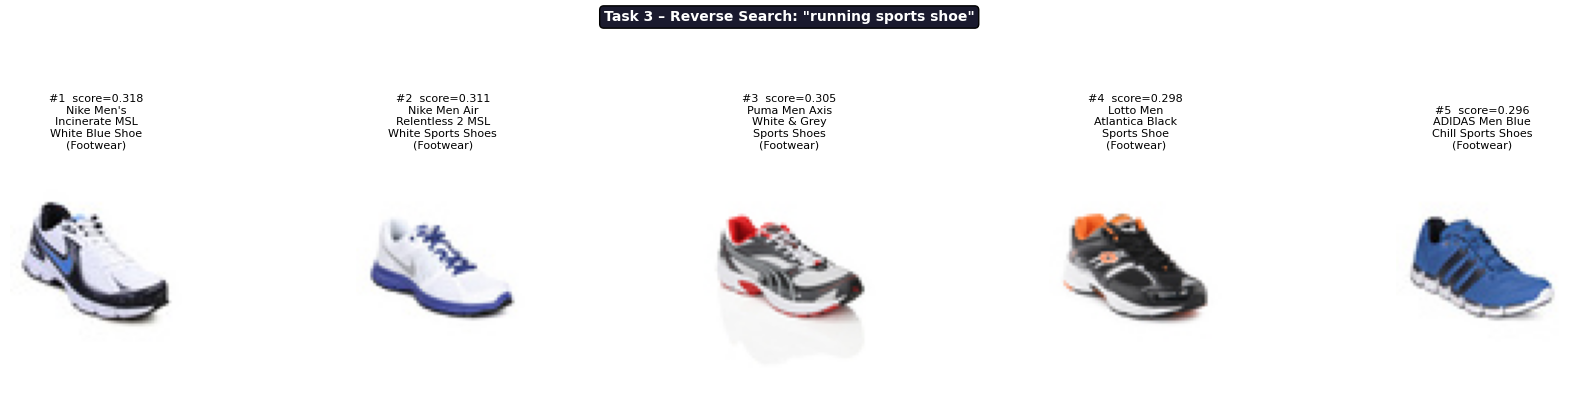

[Task3] Visualisation saved → task3_search_running_sports_shoe.png

  TASK 3 – REVERSE PRODUCT SEARCH  (Text → Image)
[Task3] Query: "black formal trousers"

─────────────────────────────────────────────
  [1] John Miller Men Solid Type Black Trousers  (cat=Apparel, score=0.315)
  [2] Manchester United Men Solid Black Track Pants  (cat=Apparel, score=0.299)
  [3] Scullers For Her Charcoal Blazer  (cat=Apparel, score=0.279)
  [4] Urban Yoga Women Blue Skirt With Leggings  (cat=Apparel, score=0.273)
  [5] Scullers Men  Grey Waistcoat  (cat=Apparel, score=0.273)


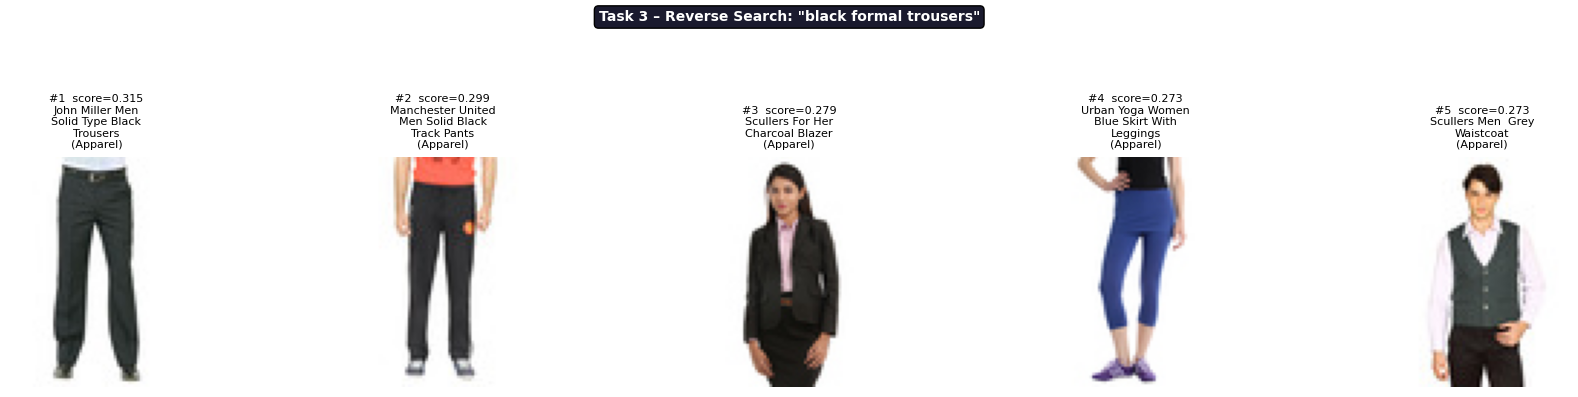

[Task3] Visualisation saved → task3_search_black_formal_trousers.png

█████████████████████████████████████████████████████████████████
  ALL TASKS COMPLETE
  Outputs: task1_recommendations.png
           task2_dedup_catalog.png
           task3_search_*.png
█████████████████████████████████████████████████████████████████


In [15]:
"""
=============================================================================
  Day 2 Homework – AI Product Intelligence System
  Gen AI Bootcamp | iDThirdeye Technology Solutions
  Student : Sanjay Srinivas B
=============================================================================
  Stack  : CLIP (ViT-B/32) · BLIP-2 · FAISS · transformers · Pillow
  Tasks  :
    Task 1 – Smart Product Recommendation Engine
    Task 2 – Unique Product Catalog Creation (De-duplication)
    Task 3 – Reverse Product Search (Text → Product)
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0.  IMPORTS & SETUP
# ─────────────────────────────────────────────────────────────────────────────
import os
import math
import textwrap
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import torch
import faiss
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from transformers import (
    CLIPProcessor, CLIPModel,
    Blip2Processor, Blip2ForConditionalGeneration,
)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Setup] Using device: {DEVICE}")

# ── Paths  (Kaggle fashion-product-images-small) ──────────────────────────────
STYLES_CSV = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv")
IMAGE_DIR  = Path("/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images")


# ─────────────────────────────────────────────────────────────────────────────
# 1.  MODEL LOADER  (load once, reuse everywhere)
# ─────────────────────────────────────────────────────────────────────────────
class ModelHub:
    """Singleton-style wrapper that loads CLIP and BLIP-2 once."""

    _clip_model    : CLIPModel                    = None
    _clip_processor: CLIPProcessor                = None
    _blip_model    : Blip2ForConditionalGeneration = None
    _blip_processor: Blip2Processor               = None

    # ── CLIP ──────────────────────────────────────────────────────────────────
    @classmethod
    def clip(cls):
        if cls._clip_model is None:
            print("[Model] Loading CLIP ViT-B/32 …")
            cls._clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            cls._clip_model      = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
            cls._clip_model.eval()
            print("[Model] CLIP ready ✓")
        return cls._clip_model, cls._clip_processor

    # ── BLIP-2 ────────────────────────────────────────────────────────────────
    @classmethod
    def blip(cls):
        if cls._blip_model is None:
            print("[Model] Loading BLIP-2 (Salesforce/blip2-opt-2.7b) …")
            cls._blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
            cls._blip_model     = Blip2ForConditionalGeneration.from_pretrained(
                "Salesforce/blip2-opt-2.7b",
                torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            ).to(DEVICE)
            cls._blip_model.eval()
            print("[Model] BLIP-2 ready ✓")
        return cls._blip_model, cls._blip_processor


# ─────────────────────────────────────────────────────────────────────────────
# 2.  EMBEDDING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def embed_images(image_paths: List[Path], batch_size: int = 32) -> np.ndarray:
    """
    Return L2-normalised CLIP image embeddings, shape (N, 512).

    The final category is selected later by argmax(cosine_similarity)
    between this embedding and category prototype embeddings — explicitly
    addresses Day-1 feedback about 'how the final category is selected'.
    """
    model, processor = ModelHub.clip()
    all_embeds = []

    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = processor(images=images, return_tensors="pt", padding=True).to(DEVICE)

        with torch.no_grad():
            feats = model.get_image_features(**inputs)           # (B, 512)
            if not isinstance(feats, torch.Tensor):
                feats = feats.pooler_output                      # unwrap if needed
            feats = feats / feats.norm(dim=-1, keepdim=True)     # L2 normalise
        all_embeds.append(feats.cpu().float().numpy())

    return np.vstack(all_embeds)                                  # (N, 512)


def embed_text(queries: List[str]) -> np.ndarray:
    """
    Return L2-normalised CLIP text embeddings, shape (N, 512).
    Used in Task 3 (reverse search) and category-prototype matching.
    """
    model, processor = ModelHub.clip()
    inputs = processor(text=queries, return_tensors="pt",
                       padding=True, truncation=True).to(DEVICE)

    with torch.no_grad():
        feats = model.get_text_features(**inputs)
        if not isinstance(feats, torch.Tensor):
            feats = feats.pooler_output
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy()


def generate_caption(image_path: Path) -> str:
    """Generate a product description using BLIP-2."""
    model, processor = ModelHub.blip()
    image  = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(
        DEVICE, torch.float16 if DEVICE == "cuda" else torch.float32
    )
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=50)
    return processor.decode(ids[0], skip_special_tokens=True).strip()


def cosine_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Cosine similarity matrix between rows of a (M,D) and b (N,D)."""
    # Both already L2-normalised → dot product == cosine similarity
    return a @ b.T                                                # (M, N)


# ─────────────────────────────────────────────────────────────────────────────
# 3.  DATASET HELPER
# ─────────────────────────────────────────────────────────────────────────────

def load_dataset(max_items: int = 500) -> List[Dict]:
    """
    Load product records from the Kaggle fashion-product-images-small dataset.

    CSV is read with:
        pd.read_csv(..., on_bad_lines='skip')
    then dropna() — exactly matching the provided notebook setup.

    Returns list of dicts: {id, name, category, sub_category, path}.
    """
    import pandas as pd

    print(f"[Dataset] Reading {STYLES_CSV} …")
    data = pd.read_csv(STYLES_CSV, on_bad_lines="skip")
    data = data.dropna()
    data = pd.DataFrame(data)

    # Normalise column names (strip whitespace)
    data.columns = data.columns.str.strip()

    print(f"[Dataset] CSV rows after dropna: {len(data)}")
    print(f"[Dataset] Columns: {list(data.columns)}")

    records = []
    for _, row in data.iterrows():
        img_path = IMAGE_DIR / f"{int(row['id'])}.jpg"
        if not img_path.exists():
            continue                                   # skip missing images
        records.append({
            "id"          : str(int(row["id"])),
            "name"        : str(row.get("productDisplayName", row["id"])),
            "category"    : str(row.get("masterCategory", "Unknown")),
            "sub_category": str(row.get("subCategory", "Unknown")),
            "article_type": str(row.get("articleType", "Unknown")),
            "colour"      : str(row.get("baseColour", "Unknown")),
            "gender"      : str(row.get("gender", "Unknown")),
            "path"        : img_path,
        })
        if len(records) >= max_items:
            break

    print(f"[Dataset] Products with valid images: {len(records)}")
    return records


# ─────────────────────────────────────────────────────────────────────────────
# TASK 1 – SMART PRODUCT RECOMMENDATION ENGINE
# ─────────────────────────────────────────────────────────────────────────────

# Co-purchase complement rules  —  keys match `masterCategory` in styles.csv
# (Apparel, Accessories, Footwear, Personal Care, Free Items, Sporting Goods, Home)
COMPLEMENT_RULES: Dict[str, List[str]] = {
    "Footwear"      : ["Accessories", "Sporting Goods", "Apparel"],
    "Apparel"       : ["Accessories", "Footwear"],
    "Accessories"   : ["Apparel", "Footwear"],
    "Sporting Goods": ["Footwear", "Accessories", "Apparel"],
    "Personal Care" : ["Apparel", "Accessories"],
    "Free Items"    : ["Apparel", "Accessories"],
    "Home"          : ["Accessories"],
}

CATEGORY_CONFIDENCE_THRESHOLD = 0.20   # min cosine-sim to assign a category


def assign_category(image_embed: np.ndarray,
                    category_list: List[str]) -> Tuple[str, float]:
    """
    Assign a product category using argmax cosine similarity between the
    image embedding and category prototype text embeddings.

    Final category = category_list[ argmax( cos_sim(img_embed, proto_embeds) ) ]
    if max_score >= CATEGORY_CONFIDENCE_THRESHOLD, else 'Unknown'.
    """
    proto_texts  = [f"a photo of a {c} product" for c in category_list]
    proto_embeds = embed_text(proto_texts)                       # (C, 512)
    scores       = cosine_sim(image_embed.reshape(1, -1),        # (1, C)
                              proto_embeds)[0]
    best_idx     = int(np.argmax(scores))
    best_score   = float(scores[best_idx])

    if best_score >= CATEGORY_CONFIDENCE_THRESHOLD:
        return category_list[best_idx], best_score
    return "Unknown", best_score


def build_faiss_index(embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Build an exact inner-product (cosine) FAISS index."""
    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings.astype(np.float32))
    return index


def task1_recommendation(query_image_path: Path,
                         products: List[Dict],
                         embeddings: np.ndarray,
                         top_k: int = 3) -> None:
    """
    Task 1: Smart Product Recommendation Engine
    ───────────────────────────────────────────
    Logic
    -----
    1. Embed the query image with CLIP.
    2. Assign its category via argmax(cosine_similarity) against category
       prototype text embeddings  [addresses Day-1 feedback].
    3. Look up COMPLEMENT_RULES to find complementary categories.
    4. From the product pool, retrieve the top-K items from each
       complementary category using FAISS vector search.
    5. Generate a BLIP-2 caption for the query product.
    6. Visualise query + recommendations.
    """
    print("\n" + "="*65)
    print("  TASK 1 – SMART PRODUCT RECOMMENDATION ENGINE")
    print("="*65)

    # Step 1 – embed query
    query_embed = embed_images([query_image_path])                # (1, 512)

    # Step 2 – assign category
    category_names = list({p["category"] for p in products})
    assigned_cat, conf = assign_category(query_embed, category_names)
    print(f"[Task1] Query category : {assigned_cat}  (confidence={conf:.3f})")

    # Step 3 – complement categories
    complements = COMPLEMENT_RULES.get(assigned_cat, category_names)
    print(f"[Task1] Complement cats: {complements}")

    # Step 4 – FAISS retrieval restricted to complement categories
    complement_mask = [
        i for i, p in enumerate(products)
        if p["category"] in complements
    ]
    if not complement_mask:
        complement_mask = list(range(len(products)))

    sub_embeds   = embeddings[complement_mask].astype(np.float32)
    sub_products = [products[i] for i in complement_mask]
    index        = build_faiss_index(sub_embeds)

    k_actual = min(top_k, len(sub_products))
    scores, indices = index.search(query_embed.astype(np.float32), k_actual)

    recommendations = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        prod = sub_products[idx]
        recommendations.append({**prod, "similarity": float(score), "rank": rank + 1})
        print(f"  [{rank+1}] {prod['name']}  "
              f"(cat={prod['category']}, sim={score:.3f})")

    # Step 5 – BLIP-2 caption
    caption = generate_caption(query_image_path)
    print(f"[Task1] BLIP-2 caption : \"{caption}\"")

    # Step 6 – Visualise
    _visualise_recommendations(query_image_path, caption,
                                assigned_cat, conf, recommendations)


def _visualise_recommendations(query_path, caption, category, conf, recs):
    n   = len(recs)
    fig = plt.figure(figsize=(4 * (n + 1), 5))
    gs  = gridspec.GridSpec(1, n + 1, figure=fig)

    # Query panel
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(Image.open(query_path).convert("RGB"))
    ax0.set_title(f"QUERY\n{textwrap.fill(caption, 18)}\ncat={category} ({conf:.2f})",
                  fontsize=8, color="navy", fontweight="bold")
    ax0.axis("off")

    # Recommendation panels
    for i, rec in enumerate(recs):
        ax = fig.add_subplot(gs[0, i + 1])
        ax.imshow(Image.open(rec["path"]).convert("RGB"))
        ax.set_title(
            f"#{rec['rank']}  sim={rec['similarity']:.2f}\n"
            f"{textwrap.fill(rec['name'], 18)}\n({rec['category']})",
            fontsize=8,
        )
        ax.axis("off")

    fig.suptitle("Task 1 – Smart Product Recommendations", fontsize=11,
                 fontweight="bold", color="white",
                 bbox=dict(facecolor="navy", boxstyle="round,pad=0.3"))
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    out = "task1_recommendations.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Task1] Visualisation saved → {out}")


# ─────────────────────────────────────────────────────────────────────────────
# TASK 2 – UNIQUE PRODUCT CATALOG CREATION  (De-duplication)
# ─────────────────────────────────────────────────────────────────────────────

DUPLICATE_THRESHOLD = 0.92   # cosine-similarity above this → duplicates


def task2_dedup_catalog(products: List[Dict],
                        embeddings: np.ndarray) -> List[Dict]:
    """
    Task 2: Unique Product Catalog Creation
    ────────────────────────────────────────
    Logic
    -----
    1. Build a pairwise cosine-similarity matrix from CLIP embeddings.
       cos_sim(A, B) = embed_A · embed_B  (both L2-normalised)
    2. Use greedy set-cover: iterate products; if a product's similarity
       to any already-chosen representative > DUPLICATE_THRESHOLD,
       it is a duplicate → grouped and discarded from the catalog.
    3. The first product in each group becomes the catalog representative.
    4. Visualise clusters.
    """
    print("\n" + "="*65)
    print("  TASK 2 – UNIQUE PRODUCT CATALOG CREATION")
    print("="*65)

    N       = len(products)
    sim_mat = cosine_sim(embeddings, embeddings)   # (N, N)  all normalised

    visited      : set         = set()
    groups       : List[List[int]] = []
    representatives: List[int] = []

    for i in range(N):
        if i in visited:
            continue
        # All products with sim > threshold are duplicates of i
        dupes = [j for j in range(N)
                 if j != i and j not in visited
                 and float(sim_mat[i, j]) >= DUPLICATE_THRESHOLD]
        group = [i] + dupes
        groups.append(group)
        representatives.append(i)
        visited.update(group)

    catalog = [products[r] for r in representatives]

    print(f"[Task2] Original count : {N}")
    print(f"[Task2] Catalog count  : {len(catalog)}")
    print(f"[Task2] Duplicates removed: {N - len(catalog)}")
    print(f"\n{'─'*45}")
    for g_idx, (rep, group) in enumerate(zip(representatives, groups)):
        rep_prod = products[rep]
        print(f"  Cluster {g_idx+1:>2} │ rep='{rep_prod['name']}'")
        for m in group[1:]:
            sim = float(sim_mat[rep, m])
            print(f"            │  dup='{products[m]['name']}'  sim={sim:.3f}")

    _visualise_catalog(products, groups, representatives)
    return catalog


def _visualise_catalog(products, groups, representatives):
    max_show  = min(6, len(groups))
    max_group = max(len(g) for g in groups[:max_show])
    fig, axes = plt.subplots(max_show, max(max_group, 1),
                             figsize=(3 * max(max_group, 1), 3 * max_show))

    if max_show == 1:
        axes = [axes]
    for row, (g, rep) in enumerate(zip(groups[:max_show], representatives[:max_show])):
        for col in range(max(max_group, 1)):
            ax = axes[row][col] if hasattr(axes[row], '__iter__') else axes[row]
            if col < len(g):
                idx = g[col]
                ax.imshow(Image.open(products[idx]["path"]).convert("RGB"))
                label = "KEPT ✓" if col == 0 else f"DUP {col}"
                color = "green" if col == 0 else "red"
                ax.set_title(f"{label}\n{products[idx]['name'][:20]}",
                             fontsize=7, color=color)
            ax.axis("off")

    fig.suptitle("Task 2 – De-duplication Clusters\n"
                 "(green=catalog representative, red=removed duplicates)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    out = "task2_dedup_catalog.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Task2] Visualisation saved → {out}")


# ─────────────────────────────────────────────────────────────────────────────
# TASK 3 – REVERSE PRODUCT SEARCH  (Text → Product)
# ─────────────────────────────────────────────────────────────────────────────

def task3_reverse_search(text_query: str,
                         products: List[Dict],
                         embeddings: np.ndarray,
                         top_k: int = 5) -> None:
    """
    Task 3: Reverse Product Search
    ───────────────────────────────
    Logic
    -----
    CLIP maps *both* images and text into the same 512-d embedding space.

    1. Encode the user's text query with CLIP's text encoder.
    2. The resulting text embedding is L2-normalised (same space as images).
    3. Cosine similarity between text_embed and all image_embeds gives a
       relevance score for each product.
       → score_i = text_embed · image_embed_i
    4. argmax(scores) is the most relevant product; top-K via FAISS.
    5. Visualise results.

    This is the core CLIP zero-shot retrieval mechanism (no fine-tuning needed).
    """
    print("\n" + "="*65)
    print("  TASK 3 – REVERSE PRODUCT SEARCH  (Text → Image)")
    print("="*65)
    print(f"[Task3] Query: \"{text_query}\"")

    text_embed = embed_text([text_query])                         # (1, 512)

    index    = build_faiss_index(embeddings.astype(np.float32))
    k_actual = min(top_k, len(products))
    scores, indices = index.search(text_embed.astype(np.float32), k_actual)

    print(f"\n{'─'*45}")
    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        prod = products[idx]
        results.append({**prod, "score": float(score), "rank": rank + 1})
        print(f"  [{rank+1}] {prod['name']}  "
              f"(cat={prod['category']}, score={score:.3f})")

    _visualise_search(text_query, results)


def _visualise_search(query, results):
    n   = len(results)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, res in zip(axes, results):
        ax.imshow(Image.open(res["path"]).convert("RGB"))
        ax.set_title(
            f"#{res['rank']}  score={res['score']:.3f}\n"
            f"{textwrap.fill(res['name'], 18)}\n({res['category']})",
            fontsize=8,
        )
        ax.axis("off")

    fig.suptitle(f'Task 3 – Reverse Search: "{query}"',
                 fontsize=10, fontweight="bold", color="white",
                 bbox=dict(facecolor="#1a1a2e", boxstyle="round,pad=0.3"))
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    safe_q = query.replace(" ", "_")[:30]
    out    = f"task3_search_{safe_q}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Task3] Visualisation saved → {out}")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

def main():
    print("\n" + "█"*65)
    print("  AI PRODUCT INTELLIGENCE SYSTEM  –  Day 2 Homework")
    print("  CLIP + BLIP-2 + FAISS")
    print("█"*65 + "\n")

    # ── 1. Load dataset ───────────────────────────────────────────────────────
    products = load_dataset(max_items=200)
    if not products:
        print("[Error] No products found. Check DATASET_ROOT path.")
        return

    # ── 2. Embed ALL product images (shared across all tasks) ─────────────────
    print(f"\n[Embed] Generating CLIP embeddings for {len(products)} products …")
    image_paths = [p["path"] for p in products]
    embeddings  = embed_images(image_paths)      # (N, 512), L2-normalised
    print(f"[Embed] Done. Embedding matrix shape: {embeddings.shape}")

    # ── TASK 1 ─────────────────────────────────────────────────────────────────
    query_path = products[0]["path"]    # use first product as query
    task1_recommendation(query_path, products, embeddings, top_k=3)

    # ── TASK 2 ─────────────────────────────────────────────────────────────────
    unique_catalog = task2_dedup_catalog(products, embeddings)
    print(f"\n[Task2] Final catalog has {len(unique_catalog)} unique products.")

    # ── TASK 3 ─────────────────────────────────────────────────────────────────
    # Run on the unique catalog (cleaner results after de-duplication)
    unique_embeds = embeddings[[products.index(p) for p in unique_catalog
                                if p in products]]
    # Fallback – embed unique catalog directly
    unique_embeds = embed_images([p["path"] for p in unique_catalog])

    task3_reverse_search("blue casual shirt",   unique_catalog, unique_embeds)
    task3_reverse_search("running sports shoe", unique_catalog, unique_embeds)
    task3_reverse_search("black formal trousers", unique_catalog, unique_embeds)

    print("\n" + "█"*65)
    print("  ALL TASKS COMPLETE")
    print("  Outputs: task1_recommendations.png")
    print("           task2_dedup_catalog.png")
    print("           task3_search_*.png")
    print("█"*65)


if __name__ == "__main__":
    main()
